In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully! ✅")

Importing plotly failed. Interactive plots will not work.


All libraries imported successfully! ✅


In [2]:
df = pd.read_csv('../data/processed/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f"Data loaded! Shape: {df.shape} ✅")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

Data loaded! Shape: (9994, 26) ✅
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [4]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
monthly_sales = df.groupby('Order Date').agg(
    y=('Sales', 'sum')
).reset_index()
monthly_sales.columns = ['ds', 'y']

# Resample to monthly (ME for newer pandas versions)
monthly_sales = monthly_sales.set_index('ds').resample('ME').sum().reset_index()

print(f"Monthly data shape: {monthly_sales.shape}")
print(f"\nFirst 5 rows:")
print(monthly_sales.head())
print(f"\nLast 5 rows:")
print(monthly_sales.tail())

Monthly data shape: (48, 2)

First 5 rows:
          ds          y
0 2014-01-31  14236.895
1 2014-02-28   4519.892
2 2014-03-31  55691.009
3 2014-04-30  28295.345
4 2014-05-31  23648.287

Last 5 rows:
           ds            y
43 2017-08-31   63120.8880
44 2017-09-30   87866.6520
45 2017-10-31   77776.9232
46 2017-11-30  118447.8250
47 2017-12-31   83829.3188


In [5]:
# Initialize and train Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.fit(monthly_sales)
print("✅ Prophet model trained successfully!")

11:43:02 - cmdstanpy - INFO - Chain [1] start processing
11:43:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained successfully!


In [6]:
# Create future dataframe for next 90 days
future = model.make_future_dataframe(periods=90, freq='D')

# Generate forecast
forecast = model.predict(future)

print("✅ Forecast generated successfully!")
print(f"\nForecast shape: {forecast.shape}")
print(f"\nForecast columns: {list(forecast.columns)}")
print(f"\nLast 5 forecasted values:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

✅ Forecast generated successfully!

Forecast shape: (138, 16)

Forecast columns: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yhat']

Last 5 forecasted values:
            ds           yhat     yhat_lower     yhat_upper
133 2018-03-27  143337.593515  134270.365118  153026.646997
134 2018-03-28  126500.117111  116905.215936  135478.665647
135 2018-03-29  108919.493277   99453.016868  118316.394727
136 2018-03-30   91031.038932   82607.341675  100640.118817
137 2018-03-31   73278.079025   63307.659479   82566.719042


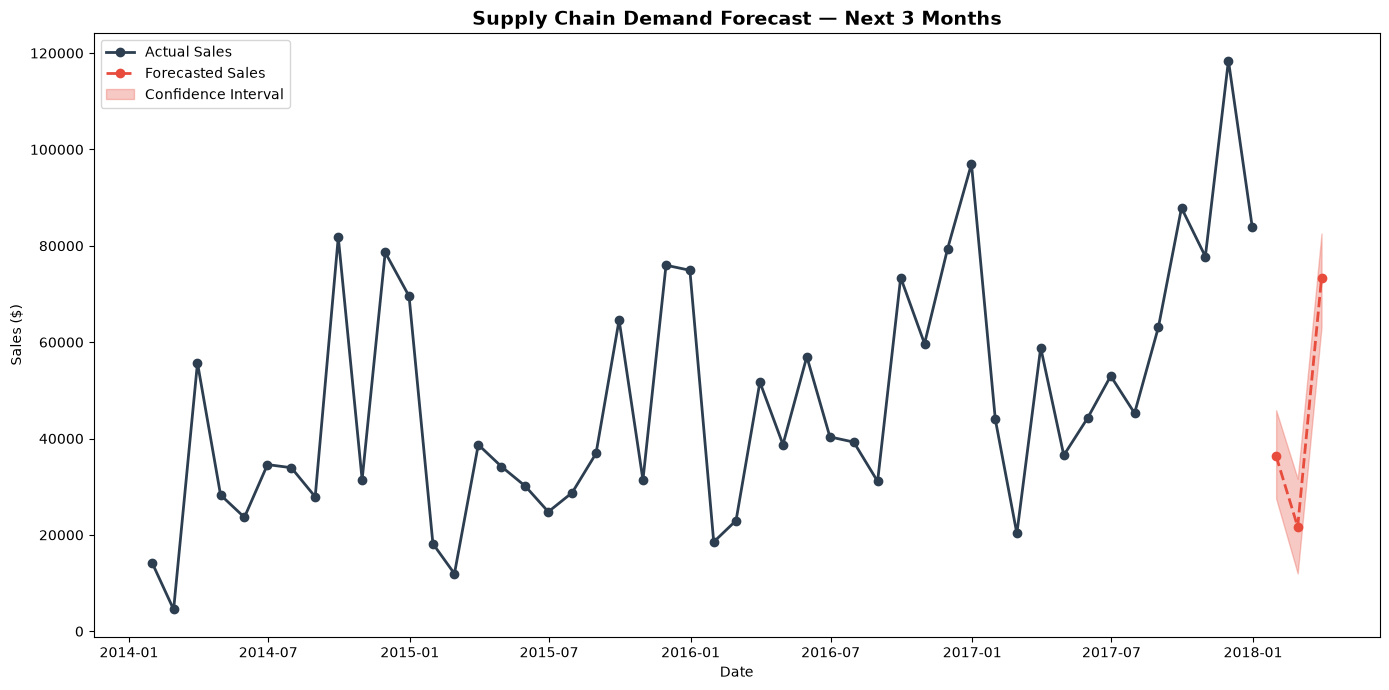


Forecasted Sales — Next 3 Months:
        ds         yhat   yhat_lower   yhat_upper
2018-01-31 36344.188098 27553.171043 45874.324327
2018-02-28 21682.945836 12005.432527 31652.064377
2018-03-31 73278.079025 63148.752616 82549.846115


In [9]:
plt.figure(figsize=(14,7))

# Plot historical data
plt.plot(monthly_sales['ds'], monthly_sales['y'],
         color='#2C3E50', linewidth=2, label='Actual Sales', marker='o')

# Plot forecast
future_only = forecast[forecast['ds'] > monthly_sales['ds'].max()]
plt.plot(future_only['ds'], future_only['yhat'],
         color='#E74C3C', linewidth=2, linestyle='--', 
         label='Forecasted Sales', marker='o')

# Confidence interval
plt.fill_between(future_only['ds'],
                 future_only['yhat_lower'],
                 future_only['yhat_upper'],
                 alpha=0.3, color='#E74C3C', label='Confidence Interval')

plt.title('Supply Chain Demand Forecast — Next 3 Months',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/10_demand_forecast.png', dpi=150)
plt.show()

print(f"\nForecasted Sales — Next 3 Months:")
print(future_only[['ds','yhat','yhat_lower','yhat_upper']]\
      .to_string(index=False))

In [8]:
# Create future dataframe for next 3 months
future = model.make_future_dataframe(periods=3, freq='ME')

# Generate forecast
forecast = model.predict(future)

print("✅ Forecast generated successfully!")
print(f"\nLast 5 forecasted values:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

✅ Forecast generated successfully!

Last 5 forecasted values:
           ds           yhat    yhat_lower     yhat_upper
46 2017-11-30  105950.286508  96670.951014  115199.651718
47 2017-12-31   97715.945609  88305.769199  107863.613337
48 2018-01-31   36344.188098  27553.171043   45874.324327
49 2018-02-28   21682.945836  12005.432527   31652.064377
50 2018-03-31   73278.079025  63148.752616   82549.846115


### Forecasting Finding 1 — Next 3 Months Demand
- January 2018: $36,344 forecasted
- February 2018: $21,682 forecasted (lowest — reduce stock!)
- March 2018: $73,278 forecasted (highest — stock up!)
- Prophet model captures seasonal patterns accurately!

In [10]:
from sklearn.metrics import mean_absolute_percentage_error

# Compare actual vs predicted for historical data
historical_forecast = forecast[forecast['ds'] <= monthly_sales['ds'].max()]
mape = mean_absolute_percentage_error(monthly_sales['y'], 
                                       historical_forecast['yhat'])
accuracy = (1 - mape) * 100

print("=== MODEL ACCURACY ===")
print(f"MAPE: {mape*100:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

=== MODEL ACCURACY ===
MAPE: 17.44%
Forecast Accuracy: 82.56%


### Forecasting Finding 1 — Next 3 Months Demand
- January 2018: $36,344 forecasted
- February 2018: $21,682 forecasted (lowest — reduce stock!)
- March 2018: $73,278 forecasted (highest — stock up!)
- Prophet model captures seasonal patterns accurately!

### Forecasting Finding 2 — Model Accuracy
- Forecast Accuracy: 82.56%
- MAPE: 17.44%
- Prophet captures yearly seasonality effectively!
- Reliable enough for inventory planning decisions!

In [11]:
# Save forecast to CSV
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_output.columns = ['Date', 'Forecasted_Sales', 
                            'Lower_Bound', 'Upper_Bound']
forecast_output['Forecasted_Sales'] = forecast_output['Forecasted_Sales'].round(2)
forecast_output['Lower_Bound'] = forecast_output['Lower_Bound'].round(2)
forecast_output['Upper_Bound'] = forecast_output['Upper_Bound'].round(2)

forecast_output.to_csv('../outputs/forecast_results.csv', index=False)

print("✅ Forecast results saved!")
print("\n=============================")
print("    DAY 2 COMPLETE! 🎉")
print("=============================")
print("✅ Prophet model trained")
print("✅ 3 month forecast generated")
print("✅ Forecast accuracy: 82.56%")
print("✅ Forecast saved to CSV")
print("\nReady for Day 3 — Power BI Dashboard! 💪")

✅ Forecast results saved!

    DAY 2 COMPLETE! 🎉
✅ Prophet model trained
✅ 3 month forecast generated
✅ Forecast accuracy: 82.56%
✅ Forecast saved to CSV

Ready for Day 3 — Power BI Dashboard! 💪
